#  Minería de Datos - Examen

## Objetivo
Desarrollar modelos de minería de datos para:
- Predecir si lloverá mañana (clasificación)
- Estimar la cantidad de lluvia (regresión)
- Identificar patrones mediante clustering

Dataset: weatherAUS.csv

In [ ]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

# Métricas
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

##  Carga de Datos

In [ ]:
df = pd.read_csv("weatherAUS.csv")

# ✅ evitar crash
df = df.sample(20000, random_state=42)

# ✅ corregir fecha
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [ ]:
##  Exploración Inicial

In [ ]:
print(df.shape)
df.info()
df.describe()


(20000, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 56320 to 65388
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           20000 non-null  datetime64[ns]
 1   Location       20000 non-null  object        
 2   MinTemp        19925 non-null  float64       
 3   MaxTemp        19959 non-null  float64       
 4   Rainfall       19838 non-null  float64       
 5   Evaporation    11489 non-null  float64       
 6   Sunshine       10488 non-null  float64       
 7   WindGustDir    18686 non-null  object        
 8   WindGustSpeed  18690 non-null  float64       
 9   WindDir9am     18627 non-null  object        
 10  WindDir3pm     19468 non-null  object        
 11  WindSpeed9am   19817 non-null  float64       
 12  WindSpeed3pm   19628 non-null  float64       
 13  Humidity9am    19747 non-null  float64       
 14  Humidity3pm    19502 non-null  float64       
 15  Pressure

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,20000,19925.000000,19959.000000,19838.000000,11489.000000,10488.000000,18690.000000,19817.000000,19628.000000,19747.000000,19502.000000,18032.000000,18037.000000,12516.000000,12022.000000,19876.000000,19623.000000,20000.000000
mean,2013-04-03 12:11:05.280000256,12.196612,23.202971,2.333950,5.451441,7.630749,40.020171,14.036080,18.660536,69.006887,51.532715,1017.680579,1015.274730,4.458933,4.506072,16.971176,21.682923,2.406195
min,2007-11-02 00:00:00,-8.000000,-3.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,984.600000,977.100000,0.000000,0.000000,-5.900000,-5.100000,0.000000
25%,2011-01-04 18:00:00,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.000000,1010.400000,1.000000,2.000000,12.200000,16.600000,0.000000
50%,2013-05-29 00:00:00,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.300000,5.000000,5.000000,16.700000,21.200000,0.000000
75%,2015-06-22 00:00:00,16.900000,28.200000,0.600000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.100000,7.000000,7.000000,21.500000,26.400000,0.600000
max,2017-06-25 00:00:00,31.400000,47.000000,278.400000,60.800000,14.100000,135.000000,87.000000,83.000000,100.000000,100.000000,1040.900000,1039.600000,8.000000,8.000000,37.700000,45.900000,268.600000
std,NaN,6.446678,7.128217,8.400646,4.050693,3.777737,13.690551,8.909016,8.842136,18.941544,20.673850,7.099862,7.045023,2.886837,2.705140,6.509648,6.928580,8.564750


In [ ]:
df.isnull().sum()


,0
Date,0
Location,0
MinTemp,75
MaxTemp,41
Rainfall,162
Evaporation,8511
Sunshine,9512
WindGustDir,1314
WindGustSpeed,1310
WindDir9am,1373


##  Limpieza de Datos

In [ ]:
# Eliminar columnas con muchos valores nulos
df = df.drop(columns=["Evaporation", "Sunshine"])

In [ ]:
# Rellenar valores nulos numéricos
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Rellenar valores restantes
df = df.ffill()


In [ ]:
# Codificar variables categóricas
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    if col not in ['Date', 'Location']:
        df[col] = le.fit_transform(df[col].astype(str))


##  Análisis Exploratorio (EDA)

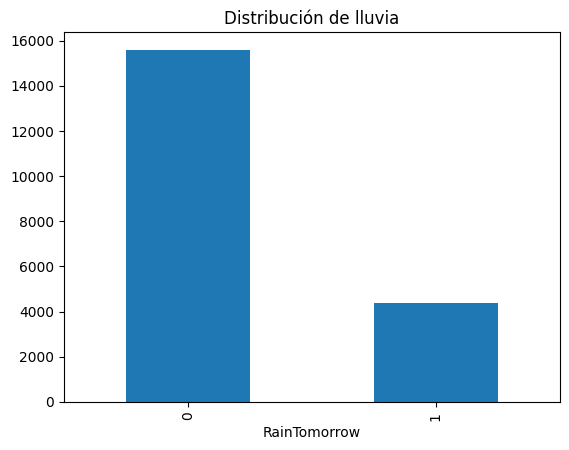

In [ ]:
df['RainTomorrow'].value_counts().plot(kind='bar')
plt.title("Distribución de lluvia")
plt.show()

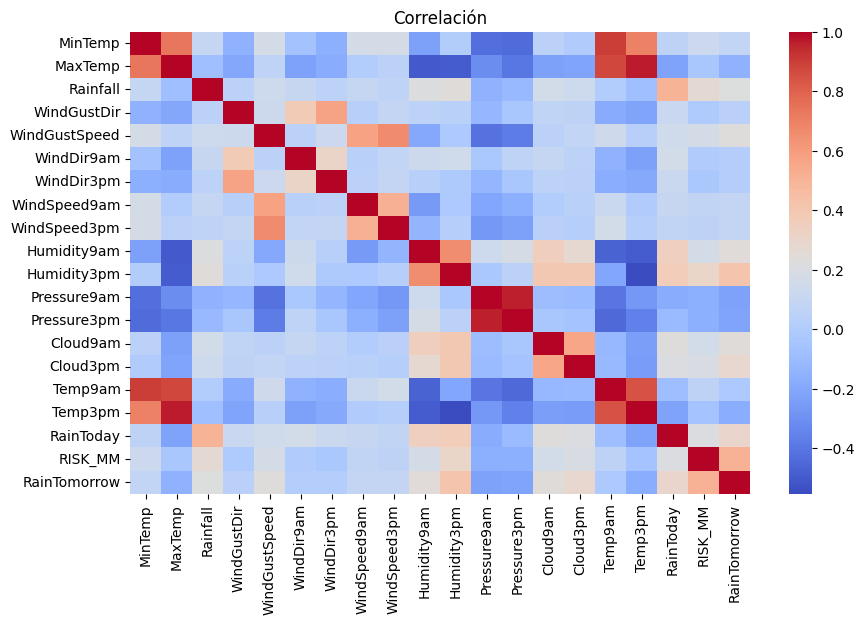

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')

plt.title("Correlación")
plt.show()

##Definición de Variables

In [ ]:
X = df.drop(["RainTomorrow", "RISK_MM", "Date", "Location"], axis=1)


y_class = df["RainTomorrow"]
y_reg = df["RISK_MM"]

In [ ]:
X_train, X_test, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)


##  Modelos Supervisados - Clasificación

In [ ]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train_c)

pred_lr = model_lr.predict(X_test)

print("Accuracy LR:", accuracy_score(y_test_c, pred_lr))

Accuracy LR: 0.82825


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Random Forest
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train_c)

pred_rf = model_rf.predict(X_test)

print("Accuracy RF:", accuracy_score(y_test_c, pred_rf))


Accuracy RF: 0.831


In [ ]:
# KNN
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train_c)

pred_knn = model_knn.predict(X_test)

print("Accuracy KNN:", accuracy_score(y_test_c, pred_knn))

Accuracy KNN: 0.82825


##  Modelos Supervisados - Regresión

In [ ]:
# Linear
model_lin = LinearRegression()
model_lin.fit(X_train_r, y_train_r)

pred_lin = model_lin.predict(X_test_r)

print("MSE:", mean_squared_error(y_test_r, pred_lin))


MSE: 63.21167149505878


In [ ]:
# Random Forest Regressor
model_rfr = RandomForestRegressor()
model_rfr.fit(X_train_r, y_train_r)

pred_rfr = model_rfr.predict(X_test_r)

print("MSE RF:", mean_squared_error(y_test_r, pred_rfr))

MSE RF: 60.46987801775


In [ ]:
# Decision Tree
model_dt = DecisionTreeRegressor()
model_dt.fit(X_train_r, y_train_r)

pred_dt = model_dt.predict(X_test_r)

print("MSE DT:", mean_squared_error(y_test_r, pred_dt))

MSE DT: 97.408595


##  Validación de Modelos


In [ ]:
print("Clasificación:")
print("LR:", accuracy_score(y_test_c, pred_lr))
print("RF:", accuracy_score(y_test_c, pred_rf))
print("KNN:", accuracy_score(y_test_c, pred_knn))

print("\nRegresión:")
print("Linear:", mean_squared_error(y_test_r, pred_lin))
print("RF:", mean_squared_error(y_test_r, pred_rfr))
print("DT:", mean_squared_error(y_test_r, pred_dt))


Clasificación:
LR: 0.82825
RF: 0.831
KNN: 0.82825

Regresión:
Linear: 63.21167149505878
RF: 60.46987801775
DT: 97.408595


## Modelos No Supervisados


In [ ]:
# KMeans
kmeans = KMeans(n_clusters=3)
df['cluster_kmeans'] = kmeans.fit_predict(X)


In [ ]:
# DBSCAN
db = DBSCAN(eps=3)
df['cluster_dbscan'] = db.fit_predict(X)

In [ ]:
# Jerárquico
hc = AgglomerativeClustering(n_clusters=3)
df['cluster_hc'] = hc.fit_predict(X)


##  Exportación de Datos para Looker Studio

In [ ]:
df['pred_lluvia'] = model_rf.predict(X)
df['pred_riesgo'] = model_rfr.predict(X)

# Clasificación del riesgo de lluvia:
# Alto si > 5 mm, Bajo si ≤ 5 mm

df['nivel_riesgo'] = df['pred_riesgo'].apply(lambda x: "Alto" if x > 5 else "Bajo")

df.to_excel("dataset_final.xlsx", index=False)

from google.colab import files
files.download("dataset_final.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>